In [ ]:
# Pull latest changes from GitHub (Colab safe)
import os
REPO_DIR = "/content/visual-finetune-lab"
if os.path.exists(REPO_DIR):
    !git -C /content/visual-finetune-lab pull
else:
    !git clone https://github.com/tdutra-dev/visual-finetune-lab.git /content/visual-finetune-lab

# Visual Fine-Tune Lab — Pipeline Notebook
**Fine-tune Phi-3.5-Vision with QLoRA on your own document images**

| Ambiente | Fasi disponibili |
|---|---|
| **JupyterLab locale (no GPU)** | 1. Preprocessing · 2. Dataset GPT-4o · 3. Config MLflow · FastAPI |
| **Google Colab T4** | Tutte le fasi (1→7) incluso fine-tuning |

Per il training su Colab: Runtime → Change runtime type → **T4 GPU**

Pipeline:
1. Install dependencies  
2. Preprocess images con OpenCV  
3. Genera dataset Q&A via GPT-4o Vision  
4. QLoRA fine-tune Phi-3.5-vision-instruct *(richiede GPU)*  
5. Evaluation BLEU + ROUGE-L + LLM-as-judge *(richiede GPU)*  
6. MLflow tracking  
7. Pipeline end-to-end


---
## 1. Environment Setup & Dependencies

In [20]:
# Check GPU availability
import subprocess, sys

result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
IS_GPU_AVAILABLE = result.returncode == 0

if IS_GPU_AVAILABLE:
    print(result.stdout[:500])
else:
    print("⚠️  Nessuna GPU trovata — esecuzione in modalità CPU.")
    print("   Fasi 1-3 (preprocessing + dataset) funzionano normalmente.")
    print("   Fase 4 (fine-tuning) verrà saltata: richiede GPU T4.")
    print("   Per il training usa Google Colab: Runtime → Change runtime type → T4 GPU.")


⚠️  Nessuna GPU trovata — esecuzione in modalità CPU.
   Fasi 1-3 (preprocessing + dataset) funzionano normalmente.
   Fase 4 (fine-tuning) verrà saltata: richiede GPU T4.
   Per il training usa Google Colab: Runtime → Change runtime type → T4 GPU.


In [ ]:
%pip install -q \
    "opencv-python-headless>=4.9" \
    "Pillow>=10.3" \
    "openai>=1.30" \
    "transformers>=4.41,<5" \
    "peft>=0.11" \
    "bitsandbytes>=0.43" \
    "accelerate>=0.30" \
    "datasets>=2.19" \
    "torchvision>=0.18" \
    "mlflow>=2.13" \
    "dagshub" \
    "nltk>=3.8" \
    "rouge-score>=0.1.2" \
    "fastapi>=0.111" \
    "python-dotenv>=1.0" \
    "structlog>=24.1" \
    "tqdm>=4.66"

In [21]:
# Detect environment: Colab vs JupyterLab locale
import os, pathlib, sys

try:
    from google.colab import drive
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

if IS_COLAB:
    REPO_URL = "https://github.com/tdutra-dev/visual-finetune-lab"
    REPO_DIR = pathlib.Path("/content/visual-finetune-lab")
    if not REPO_DIR.exists():
        os.system(f"git clone {REPO_URL} {REPO_DIR}")
    os.chdir(REPO_DIR)
    os.system("pip install -q --force-reinstall --no-deps -e '.[dev]'")
    drive.mount("/content/drive")
    DRIVE_DIR = pathlib.Path("/content/drive/MyDrive/visual-finetune-lab")
    DRIVE_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Colab — Drive montato. Working dir: {DRIVE_DIR}")
else:
    # Locale: repo già disponibile, calcola il percorso root dal notebook
    REPO_DIR = pathlib.Path(__file__).resolve().parent.parent if "__file__" in dir() else pathlib.Path.cwd().parent
    # Fallback: cerca pyproject.toml risalendo la gerarchia
    _p = pathlib.Path.cwd()
    for _ in range(5):
        if (_p / "pyproject.toml").exists():
            REPO_DIR = _p
            break
        _p = _p.parent
    DRIVE_DIR = REPO_DIR
    os.chdir(REPO_DIR)
    if str(REPO_DIR / "src") not in sys.path:
        sys.path.insert(0, str(REPO_DIR / "src"))
    print(f"JupyterLab locale — REPO_DIR: {REPO_DIR}")


JupyterLab locale — REPO_DIR: /home/tendresse/projects/visual-finetune-lab


In [ ]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Carica da .env (funziona sia locale che su Colab)
load_dotenv(REPO_DIR / '.env')

# Su Colab: prova a leggere dai Secrets di Colab
if IS_COLAB:
    try:
        from google.colab import userdata
        os.environ.setdefault('OPENAI_API_KEY', userdata.get('OPENAI_API_KEY') or '')
        os.environ.setdefault('DAGSHUB_TOKEN', userdata.get('DAGSHUB_TOKEN') or '')
    except Exception:
        pass

required = ['OPENAI_API_KEY']
missing = [k for k in required if not os.environ.get(k)]
if missing:
    raise ValueError(f'Missing environment variables: {missing}')

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
DAGSHUB_TOKEN = os.environ.get('DAGSHUB_TOKEN', '')
BASE_MODEL_ID = os.environ.get('BASE_MODEL_ID', 'microsoft/Phi-3.5-vision-instruct')

import mlflow
if DAGSHUB_TOKEN:
    import dagshub
    dagshub.auth.add_app_token(token=DAGSHUB_TOKEN)
    dagshub.init(repo_owner='tdutra-dev', repo_name='visual-finetune-lab', mlflow=True)
    MLFLOW_TRACKING_URI = mlflow.get_tracking_uri()
    print(f'MLflow tracking: DagsHub ({MLFLOW_TRACKING_URI})')
else:
    MLFLOW_TRACKING_URI = f'sqlite:///{REPO_DIR}/mlflow.db'
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    print(f'MLflow tracking: locale ({MLFLOW_TRACKING_URI})')

print(f"OPENAI_API_KEY: {'*' * 8}{OPENAI_API_KEY[-4:]}")
print(f'BASE_MODEL_ID: {BASE_MODEL_ID}')


OPENAI_API_KEY: ********KN4A
MLFLOW_TRACKING_URI: sqlite:///mlflow.db
BASE_MODEL_ID: microsoft/Phi-3.5-vision-instruct


---
## 2. Image Preprocessing with OpenCV

Upload your images to `data/raw/` on Drive, or use the sample below.

In [23]:
import pathlib
import numpy as np
from PIL import Image, ImageDraw

# Create sample directory
RAW_DIR = REPO_DIR / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

# Generate a synthetic invoice-like image (no external download needed)
sample_path = RAW_DIR / "sample_invoice.png"
if not sample_path.exists():
    img = Image.new("RGB", (800, 600), color=(255, 255, 255))
    draw = ImageDraw.Draw(img)
    draw.rectangle([40, 40, 760, 100], fill=(30, 80, 160))
    draw.text((50, 55), "INVOICE #2024-001", fill="white")
    draw.text((50, 130), "Date: 2024-01-15", fill=(50, 50, 50))
    draw.text((50, 160), "Customer: Acme Corp", fill=(50, 50, 50))
    draw.line([40, 200, 760, 200], fill=(200, 200, 200), width=2)
    draw.text((50, 220), "Description", fill=(30, 80, 160))
    draw.text((500, 220), "Amount", fill=(30, 80, 160))
    items = [("Consulting Services", "$1,200.00"),
             ("Software License", "$450.00"),
             ("Support -- 3 months", "$300.00")]
    y = 260
    for desc, amt in items:
        draw.text((50, y), desc, fill=(60, 60, 60))
        draw.text((500, y), amt, fill=(60, 60, 60))
        y += 40
    draw.line([40, y+10, 760, y+10], fill=(200, 200, 200), width=2)
    draw.text((400, y+30), "TOTAL: $1,950.00", fill=(30, 80, 160))
    img.save(sample_path)
    print(f"Generated sample invoice -> {sample_path}")

# Copy images from Drive if available
drive_raw = DRIVE_DIR / "raw"
if drive_raw.exists():
    import shutil
    for img_file in drive_raw.glob("*.*"):
        shutil.copy(img_file, RAW_DIR / img_file.name)
    print(f"Copied {len(list(drive_raw.glob('*.*')))} images from Drive")

print(f"Images in {RAW_DIR}: {[p.name for p in RAW_DIR.glob('*.*')]}")


Images in /home/tendresse/projects/visual-finetune-lab/data/raw: ['paypal_invoice.png', 'sample_invoice.png']


Processed 2 images


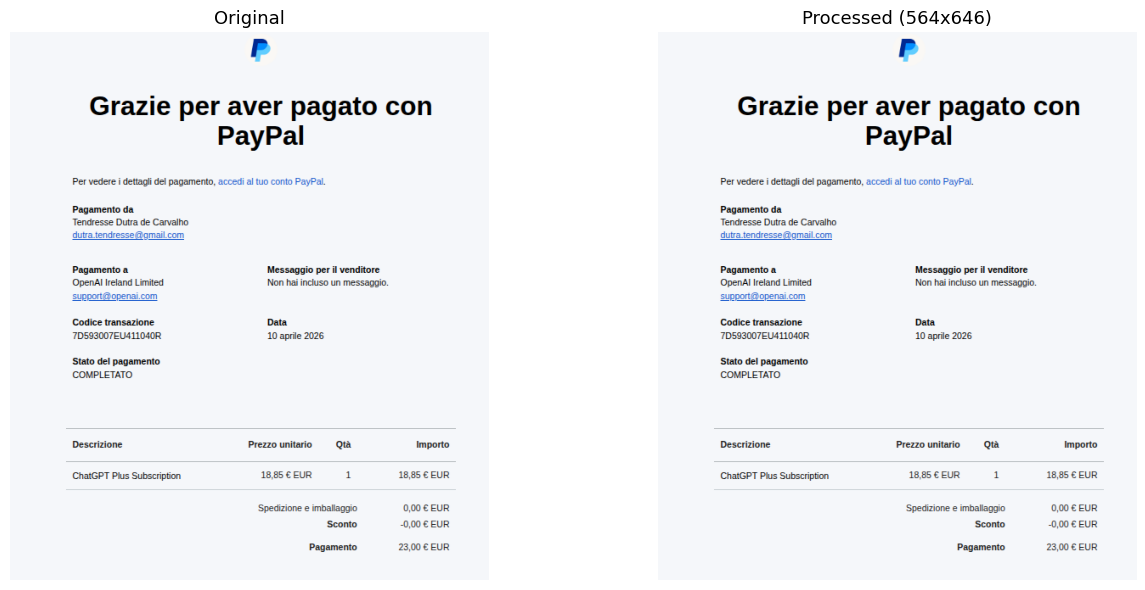

Detected regions: [{'label': 'region_13', 'bbox': [52, 69, 489, 77]}, {'label': 'region_12', 'bbox': [32, 166, 384, 22]}, {'label': 'region_11', 'bbox': [32, 199, 223, 52]}, {'label': 'region_10', 'bbox': [32, 270, 193, 53]}, {'label': 'region_9', 'bbox': [262, 270, 228, 37]}, {'label': 'region_8', 'bbox': [32, 332, 191, 36]}, {'label': 'region_7', 'bbox': [262, 332, 152, 38]}, {'label': 'region_6', 'bbox': [32, 378, 189, 36]}, {'label': 'region_4', 'bbox': [239, 476, 323, 22]}, {'label': 'region_3', 'bbox': [254, 512, 308, 21]}, {'label': 'region_1', 'bbox': [251, 551, 311, 40]}, {'label': 'region_0', 'bbox': [311, 597, 251, 22]}]


In [24]:
import sys
sys.path.insert(0, str(REPO_DIR / "src"))

from visual_finetune_lab.preprocessing import ImageProcessor
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

processor = ImageProcessor(max_size=1344)
processed = processor.process_batch(RAW_DIR)
print(f"Processed {len(processed)} images")

# Visualize first image before/after
if processed:
    sample = processed[0]
    # ProcessedImage.path is the processed file; reload original from RAW_DIR
    original = np.array(Image.open(RAW_DIR / sample.path.name))
    result = np.array(Image.fromarray(sample.array[:, :, ::-1]))  # BGR -> RGB

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(original)
    axes[0].set_title("Original", fontsize=13)
    axes[0].axis("off")
    axes[1].imshow(result)
    axes[1].set_title(f"Processed ({sample.width}x{sample.height})", fontsize=13)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
    print(f"Detected regions: {sample.regions}")


---
## 3. Synthetic Dataset Generation with GPT-4o Vision

Each preprocessed image is sent to GPT-4o Vision, which generates 5–10 Q&A pairs per image.
The result is saved as a JSONL file compatible with the HuggingFace `datasets` library.

In [25]:
from visual_finetune_lab.dataset import SyntheticDatasetGenerator
import json

DATASET_DIR = REPO_DIR / "data" / "datasets"
DATASET_DIR.mkdir(parents=True, exist_ok=True)
DATASET_PATH = DATASET_DIR / "dataset.jsonl"

generator = SyntheticDatasetGenerator()

if not DATASET_PATH.exists() or DATASET_PATH.stat().st_size == 0:
    print(f"Generating Q&A pairs for {len(processed)} images...")
    samples = generator.generate(processed)
    generator.save(samples, DATASET_PATH)
    print(f"Saved {len(samples)} samples -> {DATASET_PATH}")
else:
    print(f"Dataset already exists: {DATASET_PATH}")

# Preview first 3 samples
print("\n--- Dataset Preview ---")
with open(DATASET_PATH) as f:
    for i, line in enumerate(f):
        if i >= 3:
            break
        sample = json.loads(line)
        q = sample["question"]
        a = sample["answer"]
        img = sample["image_path"]
        print(f"[{i+1}] image: {img}")
        print(f"     Q: {q[:80]}")
        print(f"     A: {a[:120]}\n")


Dataset already exists: /home/tendresse/projects/visual-finetune-lab/data/datasets/dataset.jsonl

--- Dataset Preview ---
[1] image: /home/tendresse/projects/visual-finetune-lab/data/raw/paypal_invoice.png
     Q: Who is the payment confirmation from?
     A: PayPal

[2] image: /home/tendresse/projects/visual-finetune-lab/data/raw/paypal_invoice.png
     Q: What is the date of the transaction?
     A: 10 aprile 2026

[3] image: /home/tendresse/projects/visual-finetune-lab/data/raw/paypal_invoice.png
     Q: Who made the payment?
     A: Tendresse Dutra de Carvalho



In [26]:
# Copy dataset to Drive for persistence
import shutil

drive_datasets = DRIVE_DIR / "datasets"
drive_datasets.mkdir(parents=True, exist_ok=True)
shutil.copy(DATASET_PATH, drive_datasets / "dataset.jsonl")
print(f"Dataset backed up to Drive: {drive_datasets / 'dataset.jsonl'}")

# Count samples
with open(DATASET_PATH) as f:
    n = sum(1 for _ in f)
print(f"Total samples: {n}")

Dataset backed up to Drive: /home/tendresse/projects/visual-finetune-lab/datasets/dataset.jsonl
Total samples: 20


---
## 4. QLoRA Fine-Tuning with PEFT

Loads `Phi-3.5-vision-instruct` in **4-bit NF4** (uses ~6 GB VRAM on T4).  
LoRA adapters are attached only to attention projections — total trainable params ≈ 20M.

| Hyper-parameter | Default | Notes |
|---|---|---|
| `lora_rank` | 16 | Higher = more capacity, more VRAM |
| `lora_alpha` | 32 | Typically 2× rank |
| `num_epochs` | 3 | 3 epochs on ~100 samples takes ~15 min on T4 |
| `batch_size` | 2 | With grad. accum. 4 → effective batch 8 |

In [27]:
# Training hyper-parameters — edit these freely
LORA_RANK       = 16
LORA_ALPHA      = 32
NUM_EPOCHS      = 3
BATCH_SIZE      = 2
GRAD_ACCUM      = 4
LEARNING_RATE   = 2e-4
CHECKPOINT_DIR  = REPO_DIR / "checkpoints"

In [28]:
if not IS_GPU_AVAILABLE:
    print("⏭️  Fine-tuning saltato: nessuna GPU disponibile.")
    print("   Apri questo notebook su Google Colab con runtime T4 per eseguire questa fase.")
    checkpoint_path = REPO_DIR / "checkpoints" / "best"  # placeholder
else:
    from visual_finetune_lab.training import LoRATrainer, TrainingConfig

    config = TrainingConfig(
        base_model_id=BASE_MODEL_ID,
        output_dir=str(CHECKPOINT_DIR),
        num_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LEARNING_RATE,
        lora_rank=LORA_RANK,
        lora_alpha=LORA_ALPHA,
        mlflow_experiment="visual-finetune-lab-colab",
    )

    trainer = LoRATrainer(config)
    checkpoint_path = trainer.train(dataset_path=DATASET_PATH)
    print(f"\nCheckpoint salvato in: {checkpoint_path}")


⏭️  Fine-tuning saltato: nessuna GPU disponibile.
   Apri questo notebook su Google Colab con runtime T4 per eseguire questa fase.


In [29]:
if not IS_GPU_AVAILABLE:
    print("⏭️  Backup checkpoint saltato: nessun checkpoint prodotto in modalità CPU.")
elif IS_COLAB:
    import shutil
    drive_ckpt = DRIVE_DIR / "checkpoints" / "best"
    drive_ckpt.parent.mkdir(parents=True, exist_ok=True)
    if checkpoint_path.exists():
        shutil.copytree(checkpoint_path, drive_ckpt, dirs_exist_ok=True)
        print(f"Adapter backup su Drive: {drive_ckpt}")
        adapter_files = list(drive_ckpt.glob("*"))
        print(f"Files: {[f.name for f in adapter_files]}")
else:
    print(f"Checkpoint locale in: {checkpoint_path}")


⏭️  Backup checkpoint saltato: nessun checkpoint prodotto in modalità CPU.


---
## 5. Evaluation: BLEU, ROUGE-L & LLM-as-Judge

Hold out 10% of samples automatically. Metrics:
- **BLEU**: n-gram overlap with reference answers  
- **ROUGE-L**: longest common subsequence ratio  
- **LLM-as-judge**: GPT-4o scores each prediction 1–5 for accuracy

In [30]:
import json, math

# Build held-out test set (last 10% of dataset)
with open(DATASET_PATH) as f:
    all_samples = [json.loads(l) for l in f]

n_test = max(1, math.ceil(len(all_samples) * 0.1))
test_raw = all_samples[-n_test:]

# Dataset format: {"image_path": ..., "question": ..., "answer": ..., "source_description": ...}
test_samples = [
    {"question": s["question"], "answer": s["answer"], "image_path": s["image_path"]}
    for s in test_raw
]

print(f"Total samples : {len(all_samples)}")
print(f"Train samples : {len(all_samples) - n_test}")
print(f"Eval samples  : {len(test_samples)}")


Total samples : 20
Train samples : 18
Eval samples  : 2


In [ ]:
# Compatibility patch: transformers >=5.x removed several DynamicCache methods
# that Phi-3.5-vision's custom forward still calls. Restore all missing ones.
from transformers import DynamicCache

if not hasattr(DynamicCache, "from_legacy_cache"):
    @classmethod
    def _from_legacy_cache(cls, past_key_values=None):
        cache = cls()
        if past_key_values is not None:
            for layer_idx, (keys, values) in enumerate(past_key_values):
                cache.update(keys, values, layer_idx)
        return cache
    DynamicCache.from_legacy_cache = _from_legacy_cache
    print("Patched: from_legacy_cache")

if not hasattr(DynamicCache, "get_usable_length"):
    def _get_usable_length(self, new_seq_length: int, layer_idx: int = 0) -> int:
        return self.get_seq_length(layer_idx)
    DynamicCache.get_usable_length = _get_usable_length
    print("Patched: get_usable_length")

if not hasattr(DynamicCache, "get_max_length"):
    def _get_max_length(self) -> None:
        return None
    DynamicCache.get_max_length = _get_max_length
    print("Patched: get_max_length")

if not hasattr(DynamicCache, "to_legacy_cache"):
    def _to_legacy_cache(self):
        return tuple(
            (self.key_cache[i], self.value_cache[i])
            for i in range(len(self.key_cache))
        )
    DynamicCache.to_legacy_cache = _to_legacy_cache
    print("Patched: to_legacy_cache")

if not hasattr(DynamicCache, "seen_tokens"):
    DynamicCache.seen_tokens = property(lambda self: self.get_seq_length(0))
    print("Patched: seen_tokens")

print("DynamicCache patch complete.")

DynamicCache patch complete.


In [32]:
if not IS_GPU_AVAILABLE:
    print("⏭️  Evaluation saltata: nessuna GPU disponibile.")
    print("   Esegui questa cella su Google Colab T4 dopo il fine-tuning.")
    avg_bleu = avg_rouge = avg_judge = 0.0
    results = []
else:
    from visual_finetune_lab.evaluation import ModelEvaluator

    evaluator = ModelEvaluator(checkpoint_path=checkpoint_path)
    results = evaluator.evaluate(test_samples)

    # Summary table
    print(f"{'Question':<50} {'BLEU':>6} {'ROUGE-L':>8} {'LLM':>5}")
    print("-" * 75)
    for r in results:
        print(f"{r.question[:48]:<50} {r.bleu:>6.3f} {r.rouge_l:>8.3f} {r.llm_judge_score:>5.1f}")

    avg_bleu   = sum(r.bleu for r in results) / len(results)
    avg_rouge  = sum(r.rouge_l for r in results) / len(results)
    avg_judge  = sum(r.llm_judge_score for r in results) / len(results)
    print("-" * 75)
    print(f"{'AVERAGE':<50} {avg_bleu:>6.3f} {avg_rouge:>8.3f} {avg_judge:>5.1f}")


⏭️  Evaluation saltata: nessuna GPU disponibile.
   Esegui questa cella su Google Colab T4 dopo il fine-tuning.


---
## 6. MLflow Experiment Tracking

"Logs are written to **DagsHub** (if `DAGSHUB_TOKEN` is set in Colab Secrets 🔑) or SQLite fallback.  
"
"For Colab: add `DAGSHUB_TOKEN` and `OPENAI_API_KEY` to Colab Secrets."

In [33]:
import mlflow
import os

os.environ.setdefault("MLFLOW_TRACKING_URI", MLFLOW_TRACKING_URI)
mlflow.set_experiment("visual-finetune-lab-colab")

with mlflow.start_run(run_name=f"qlora-r{LORA_RANK}-e{NUM_EPOCHS}") as run:
    # Log hyper-parameters
    mlflow.log_params({
        "base_model": BASE_MODEL_ID,
        "lora_rank": LORA_RANK,
        "lora_alpha": LORA_ALPHA,
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE * GRAD_ACCUM,
        "learning_rate": LEARNING_RATE,
        "num_train_samples": len(all_samples) - n_test,
        "num_eval_samples": n_test,
    })
    # Log evaluation metrics
    mlflow.log_metrics({
        "bleu": avg_bleu,
        "rouge_l": avg_rouge,
        "llm_judge": avg_judge,
    })
    # Log LoRA adapter as artifact
    if checkpoint_path.exists():
        mlflow.log_artifacts(str(checkpoint_path), artifact_path="lora-adapter")

    RUN_ID = run.info.run_id
    print(f"MLflow run: {RUN_ID}")
    print(f"Experiment: visual-finetune-lab-colab")
    print(f"Metrics — BLEU: {avg_bleu:.3f}  ROUGE-L: {avg_rouge:.3f}  LLM-judge: {avg_judge:.1f}/5")

MLflow run: 00b10f931a2a4a0fb51f6a511d0883f2
Experiment: visual-finetune-lab-colab
Metrics — BLEU: 0.000  ROUGE-L: 0.000  LLM-judge: 0.0/5


In [ ]:
import sys
sys.path.insert(0, str(REPO_DIR / "src"))

from visual_finetune_lab.preprocessing import ImageProcessor
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

processor = ImageProcessor(max_size=1344)
processed = processor.process_batch(RAW_DIR)
print(f"Processed {len(processed)} images")

# Visualize first image before/after
if processed:
    sample = processed[0]
    original = np.array(Image.open(sample.path))  # path originale
    result = sample.array                        # immagine processata

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(original)
    axes[0].set_title("Original", fontsize=13)
    axes[1].imshow(result)
    axes[1].set_title(f"Processed ({sample.width}x{sample.height})", fontsize=13)
    axes[0].axis('off')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    print(f"Detected regions: {sample.regions}")

MLflow Run Summary
Run ID   : 00b10f931a2a4a0fb51f6a511d0883f2
Status   : FINISHED

Parameters:
  base_model                     microsoft/Phi-3.5-vision-instruct
  lora_rank                      16
  lora_alpha                     32
  num_epochs                     3
  batch_size                     8
  learning_rate                  0.0002
  num_train_samples              18
  num_eval_samples               2

Metrics:
  bleu                           0.0000
  rouge_l                        0.0000
  llm_judge                      0.0000


---
## 7. End-to-End Pipeline Execution

Runs the full pipeline — preprocessing → dataset → fine-tune → eval — via `run_pipeline.py`.

In [19]:
import subprocess, sys

cmd = [
    sys.executable, str(REPO_DIR / "scripts" / "run_pipeline.py"),
    "--images", str(RAW_DIR),
    "--epochs", str(NUM_EPOCHS),
    "--lora-rank", str(LORA_RANK),
]
print("Running:", " ".join(cmd))

result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(REPO_DIR))
print(result.stdout)
if result.stderr:
    print("[stderr]", result.stderr[-2000:])
print(f"\nReturn code: {result.returncode}")

Running: /home/tendresse/projects/visual-finetune-lab/.venv/bin/python /home/tendresse/projects/visual-finetune-lab/scripts/run_pipeline.py --images /home/tendresse/projects/visual-finetune-lab/data/raw --epochs 3 --lora-rank 16


KeyboardInterrupt: 

In [35]:
# Verify final artifacts
print("=== Final Artifacts ===")

artifacts = {
    "Dataset (JSONL)":    DATASET_PATH,
    "LoRA adapter":       checkpoint_path / "adapter_model.safetensors",
    "Processor config":   checkpoint_path / "preprocessor_config.json",
    "MLflow DB":          REPO_DIR / "mlflow.db",
}

for label, path in artifacts.items():
    exists = path.exists()
    size = f"{path.stat().st_size / 1024:.1f} KB" if exists else "—"
    status = "✓" if exists else "✗"
    print(f"  {status} {label:<30} {size}")

=== Final Artifacts ===
  ✓ Dataset (JSONL)                5.6 KB
  ✗ LoRA adapter                   —
  ✗ Processor config               —
  ✓ MLflow DB                      648.0 KB
